In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import pickle
from pandas.api.types import is_numeric_dtype
from sklearn.model_selection import train_test_split
from scipy.stats import mannwhitneyu
from scipy.spatial.distance import cdist
from sklearn.cluster import MiniBatchKMeans
import re

import sklearn, matplotlib, scipy
import tensorflow as tf
from tensorflow import keras

In [2]:
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"SciPy version: {scipy.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

NumPy version: 1.24.4
Pandas version: 1.2.4
Scikit-learn version: 1.3.2
Matplotlib version: 3.4.1
Seaborn version: 0.11.1
SciPy version: 1.10.1
TensorFlow version: 2.7.0
Keras version: 2.7.0


In [12]:
# Pandas 출력 옵션 조정 - All
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [15]:
# Pandas 출력 옵션 조정 - Default
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

In [3]:
## Definitions

## Defines

# Data confirmmation :: Nan counts + Nan Ratios, Unique values
def analyse_dataframe(df):
    # NaN 개수, 비율 및 고유 값 개수 계산
    nan_counts = df.isnull().sum()
    nan_ratios = df.isnull().mean() * 100  # 백분율로 표시
    unique_values_count = df.nunique()

    # 결과 데이터 프레임 생성
    analysis_result = pd.DataFrame({
        'NaN Counts': nan_counts,
        'NaN Ratios (%)': nan_ratios,
        'Unique Values Count': unique_values_count
    })

    return analysis_result

def print_progress(iteration, total, prefix='', suffix='', decimals=1, length=50, fill='█', printEnd="\r"):
    """
    Call in a loop to create terminal progress bar
    @params:
        iteration   - Required  : current iteration (Int)
        total       - Required  : total iterations (Int)
        prefix      - Optional  : prefix string (Str)
        suffix      - Optional  : suffix string (Str)
        decimals    - Optional  : positive number of decimals in percent complete (Int)
        length      - Optional  : character length of bar (Int)
        fill        - Optional  : bar fill character (Str)
        printEnd    - Optional  : end character (e.g. "\r", "\r\n") (Str)
    """
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filledLength = int(length * iteration // total)
    bar = fill * filledLength + '-' * (length - filledLength)
    print(f'\r{prefix} |{bar}| {percent}% {suffix}', end=printEnd)
    # Print New Line on Complete
    if iteration == total: 
        print()

In [34]:
## Configs
base = '/media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN'
# out = f'{base}/Clustering/M01_Main'
# out = f'{base}/Clustering/M13/1_Whole'
out = f'{base}/Clustering/M14-1/1_Whole'
ipt = f'{base}/Dataset'

In [35]:
# CLUSTERING :: DATA IMPORT

# Data import
df = pd.read_csv(f"{ipt}/knn_prep-fin_M07.csv")
# df = pd.read_csv(f"{ipt}/knn_prep-fin_M06-alive.csv")
df.rename(columns={'Unnamed: 0': 'idx_code'}, inplace=True)
df.set_index('idx_code', inplace=True)
df

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (22) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,ntetoy_3,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,2013-12-18,2013-12-18,2013-12-18,4.0,5.0,1350,29,1,0,...,0,0,1,0,0,0,1,0,0,0
1,1,2013-11-15,2013-11-15,2013-11-15,4.0,5.0,790,35,1,0,...,0,0,1,0,0,0,1,0,0,0
2,1,2013-11-15,2013-11-15,2013-11-15,5.0,6.0,1400,26,1,0,...,0,0,1,0,0,0,1,0,0,0
3,1,2013-11-15,2013-11-15,2013-11-15,6.0,7.0,1340,26,1,0,...,0,0,1,0,0,0,1,0,0,0
4,1,2013-11-11,2013-11-11,2013-11-11,4.0,5.0,1240,36,4,1,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,2022-11-28,2022-11-28,2022-11-28,5.0,8.0,1350,23,1,0,...,0,0,1,0,0,0,1,0,0,0
20409,1,2022-12-27,2022-12-27,2022-12-27,4.0,7.0,860,38,3,1,...,0,0,1,0,0,0,1,0,0,0
20410,0,2022-12-01,2022-12-01,2022-12-01,5.0,7.0,1910,30,2,0,...,0,0,1,0,0,0,1,0,0,0


In [6]:
## 특정 칼럼의 값을 가진 인원만 사용

# col_name1 = 'iperr_2'
# col_name2 = 'ntet_1'
col_name = 'iperr_2'
value = 1

# df = df[(df[col_name1] == value) | (df[col_name2] == value)]    # 'OR' condition
df = df[df[col_name] == value]
num_rows = df.shape[0]
num_cols = df.shape[1]
summary_df = pd.DataFrame({
    'n_participants': [num_rows],
    'n_features': [num_cols]
})
file_name = col_name.split('_')[0] + '_Pos_DataSummary'

summary_df.to_csv(f"{out}/{file_name}.csv", index=False)
print(f"Data summary has been saved: {out}/{file_name}.csv")

df

Data summary has been saved: /media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN/Clustering/M14_dM06/2_SurvOnly/3_IBP only/iperr_Pos_DataSummary.csv


,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,ntetoy_3,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2
idx_code,,,,,,,,,,,,,,,,,,,,,
109,0,2013-07-21,2013-07-21,2013-08-03,3.0,4.0,922,38,3,2,...,1,0,0,1,0,0,0,1,0,0
202,1,2013-12-19,2013-12-19,2013-12-19,5.0,7.0,1128,32,1,0,...,0,0,0,1,0,0,0,0,1,0
243,0,2013-10-23,2013-10-23,2013-10-23,6.0,8.0,1200,22,1,0,...,0,0,0,1,0,0,0,0,1,0
250,0,2013-08-06,2013-08-06,2013-08-06,3.0,5.0,690,36,3,1,...,0,0,0,1,0,0,0,0,1,0
279,0,2013-08-23,2013-08-23,2013-08-23,1.0,4.0,1150,33,1,0,...,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19978,1,2022-04-16,2022-04-16,2022-04-16,4.0,7.0,850,30,1,0,...,0,0,0,1,0,0,0,0,1,0
20126,1,2022-07-15,2022-07-15,2022-07-15,5.0,7.0,800,25,2,1,...,0,0,0,1,0,0,0,0,1,0
20225,1,2022-06-05,2022-06-05,2022-06-05,2.0,4.0,580,34,1,0,...,0,0,0,1,0,0,0,0,1,0


In [7]:
for column in data.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {data[column].dtype}")
    print(f"유니크한 값:")
    print(data[column].unique())
    print("-" * 40)

NameError: name 'data' is not defined

In [36]:
## 기존 세팅
# datetime_cols = ['ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt'
#                  , 'acldt', 'birthdt', 'bsfdt1', 'bsfdt3', 'admd'
#                  , 'prho', 'promd', 'promh', 'prdh', 'dth36dt'    # 01-24 추가됨 ('promh', 'prdh', 'dth36dt')
#                  , 'fsfdt1', 'fsfdt2', 'birtm', 'bird']
# drop_cols = ['apguk1', 'apguk5', 'fetc2', 'fetc', 'strduot', 'metc', 'ibifcmt', 'lbpdot'
#              , 'bhdcut', 'bhtcut', 'iperrdt', 'phudot', 'phudstdt', 'sftum', 'sftuh', 'sftfudt'
#              , 'sftthdt', 'birdm', 'birdh', 'sign'
#              , 'promn'    # 01-24 추가됨
#             ]




drop_cols = []
datetime_cols = ['ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt'
                 , 'birthdt', 'admd', 'birtm', 'bird', 'efydt', 'death_dt', 'iperrdt'
                ]
drop_cols += datetime_cols
df = df.drop(columns=list(drop_cols))

tgt_cols = [col for col in df.columns if col in ['ntet', 'ntety', 'ntetoy'
                                                    , 'SEPS_bef_NTET', 'SEPS_aft_NTET'
                                                    , 'NTET_day', 'PDA_7d_NTET'
                                                    , 'invfpod'
                                                    , 'iperr', 'iperroy'
                                                    , 'SEPS_bef_IPERR', 'SEPS_aft_IPERR'
                                                    , 'IPERR_day', 'PDA_7d_IPERR'
                                                    , 'PDA_7d_IPERRorNTET'
                                                    , 'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET'
                                                   ]
            or any(col.startswith(prefix) for prefix in ['ntet', 'ntety', 'ntetoy'
                                                         , 'SEPS_bef_NTET', 'SEPS_aft_NTET'
                                                         , 'NTET_day', 'PDA_7d_NTET'
                                                         , 'invfpod'
                                                         , 'iperr', 'iperroy'
                                                         , 'SEPS_bef_IPERR', 'SEPS_aft_IPERR'
                                                         , 'IPERR_day', 'PDA_7d_IPERR'
                                                         , 'PDA_7d_IPERRorNTET'
                                                         , 'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET'
                                                        ])
           ]
data = df.drop(columns=['death_label'] + list(tgt_cols)
#                + list(drop_cols)
#                + list(datetime_cols)
              )

# 데이터 표준화 (이진 값을 제외하고 표준화 수행)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
df_scd = pd.DataFrame(scaled_data, index=data.index, columns=data.columns)

df_scd['death_label'] = df['death_label']

df_scd

,sex_sys_val,apgs1,apgs5,bwei,mage,gran,parn,bhei,bheiuk,bhead,...,arre36_0,arre36_6,arre36_7,pvl_1,pvl_3,pvl_2,seps_1,seps_2,seps_3,death_label
idx_code,,,,,,,,,,,,,,,,,,,,,
0,0.993145,-0.361034,-1.032974,0.867691,-1.020264,-0.760507,-0.636012,0.685902,-0.243254,0.827566,...,0.512989,-0.235219,-0.429770,0.348757,-0.193429,-0.279326,0.476662,-0.470286,-0.063603,0
1,0.993145,-0.361034,-1.032974,-1.001814,0.360486,-0.760507,-0.636012,-0.622812,-0.243254,-1.218738,...,0.512989,-0.235219,-0.429770,0.348757,-0.193429,-0.279326,-2.097921,2.126366,-0.063603,0
2,0.993145,0.117458,-0.497525,1.034612,-1.710639,-0.760507,-0.636012,0.685902,-0.243254,1.032196,...,0.512989,-0.235219,-0.429770,0.348757,-0.193429,-0.279326,0.476662,-0.470286,-0.063603,0
3,0.993145,0.595950,0.037925,0.834307,-1.710639,-0.760507,-0.636012,-0.149447,-0.243254,0.827566,...,0.512989,-0.235219,-0.429770,-2.867328,5.169867,-0.279326,-2.097921,2.126366,-0.063603,0
4,0.993145,-0.361034,-1.032974,0.500467,0.590611,1.748735,0.768667,1.521251,-0.243254,0.213674,...,0.512989,-0.235219,-0.429770,0.348757,-0.193429,-0.279326,0.476662,-0.470286,-0.063603,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,0.993145,0.117458,0.573375,0.867691,-2.401014,-0.760507,-0.636012,0.268227,-0.243254,0.622935,...,0.512989,-0.235219,-0.429770,0.348757,-0.193429,-0.279326,-2.097921,2.126366,-0.063603,0
20409,0.993145,-0.361034,0.037925,-0.768126,1.050861,0.912321,0.768667,-0.845572,-0.243254,-1.014108,...,-1.949359,-0.235219,2.326826,0.348757,-0.193429,-0.279326,-2.097921,2.126366,-0.063603,0
20410,-1.006903,0.117458,0.037925,2.737197,-0.790139,0.075907,-0.636012,1.660476,-0.243254,1.236826,...,0.512989,-0.235219,-0.429770,0.348757,-0.193429,-0.279326,0.476662,-0.470286,-0.063603,0


In [37]:
print(len(drop_cols))
print(len(datetime_cols))
print(len(tgt_cols))

14
14
30


In [38]:
for column in df.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df[column].dtype}")
    print(f"유니크한 값:")
    print(df[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[ 4.          5.          6.          3.          7.          1.
  9.          8.          2.          4.75271096  0.         10.        ]
----------------------------------------
칼럼 이름: apgs5
데이터 타입: float64
유니크한 값:
[ 5.          6.          7.          8.          4.          9.
  1.          3.         10.          2.          6.92736054  0.        ]
----------------------------------------
칼럼 이름: bwei
데이터 타입: int64
유니크한 값:
[1350  790 1400 1340 1240  810 1300 1380  990 1180 1475 1450 1485  960
  910  730 1370 1205 1440 1390 1480 1290 1210 1455 1200 1360 1470 1015
  860  865 1130 1090  920 1260 1220 1320  980  660  600 1270  940 1080
 1190 1490 1040  930  670 1160  480 1330 1250 1460 1310  473  840  850
 1140  610  950 1070 1060  720  680  770 1170  710 1061 1002 1120 1020
  922 1037 1031  765  438 1243  880 1306 1472  708 1376  924  970 1150
 1245 1065 1100 14

In [39]:
analyse_dataframe(df)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
apgs1,0,0.0,12
apgs5,0,0.0,12
bwei,0,0.0,902
mage,0,0.0,40
...,...,...,...
iperr_4,0,0.0,2
iperroy_1,0,0.0,2
iperroy_4,0,0.0,2
iperroy_3,0,0.0,2


In [40]:
analyse_dataframe(df_scd)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
apgs1,0,0.0,12
apgs5,0,0.0,12
bwei,0,0.0,902
mage,0,0.0,40
...,...,...,...
pvl_2,0,0.0,2
seps_1,0,0.0,2
seps_2,0,0.0,2
seps_3,0,0.0,2


In [41]:
for column in df_scd.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df_scd[column].dtype}")
    print(f"유니크한 값:")
    print(df_scd[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: float64
유니크한 값:
[ 0.99314457 -1.00690275]
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[-3.61033760e-01  1.17458148e-01  5.95950057e-01 -8.39525668e-01
  1.07444196e+00 -1.79650948e+00  2.03142578e+00  1.55293387e+00
 -1.31801758e+00 -8.67655096e-04 -2.27500139e+00  2.50991769e+00]
----------------------------------------
칼럼 이름: apgs5
데이터 타입: float64
유니크한 값:
[-1.03297435e+00 -4.97524662e-01  3.79250240e-02  5.73374710e-01
 -1.56842403e+00  1.10882440e+00 -3.17477309e+00 -2.10387372e+00
  1.64427408e+00 -2.63932340e+00 -9.69754067e-04 -3.71022278e+00]
----------------------------------------
칼럼 이름: bwei
데이터 타입: float64
유니크한 값:
[ 8.67691416e-01 -1.00181446e+00  1.03461158e+00  8.34307383e-01
  5.00467047e-01 -9.35046394e-01  7.00771249e-01  9.67843517e-01
 -3.34133791e-01  3.00162846e-01  1.28499184e+00  1.20153175e+00
  1.31837587e+00 -4.34285891e-01 -6.01206059e-01 -1.20211866e+00
  9.34459483e-01  3.83622930e-01  1.16814772e+

In [42]:
# ntet_1
# iperr_2
# death36

# 생존과 사망 비율 계산 (%)
death_label_ratio = df['iperr_2'].value_counts(normalize=True) * 100
# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = death_label_ratio[0]  # 생존 비율
died_ratio = death_label_ratio[1]      # 사망 비율
# 출력
print("[1-1, IPERR POS]")
print("[df_scd (Processed df)]")
print(f"Negatives (0): {survived_ratio:.2f}%")
print(f"Negatives / Total : {len(df[df['iperr_2'] == 0])} / {len(df['iperr_2'])}")
print("&")
print(f"Positives (1): {died_ratio:.2f}%")
print(f"Positives / Total : {len(df[df['iperr_2'] == 1])} / {len(df['iperr_2'])}")
print()


# 생존과 사망 비율 계산 (%)
death_label_ratio = df['ntet_1'].value_counts(normalize=True) * 100
# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = death_label_ratio[0]  # 생존 비율
died_ratio = death_label_ratio[1]      # 사망 비율
# 출력
print("[1-2, NTET POS]")
print("[df_scd (Processed df)]")
print(f"Negatives (0): {survived_ratio:.2f}%")
print(f"Negatives / Total : {len(df[df['ntet_1'] == 0])} / {len(df['ntet_1'])}")
print("&")
print(f"Positives (1): {died_ratio:.2f}%")
print(f"Positives / Total : {len(df[df['ntet_1'] == 1])} / {len(df['ntet_1'])}")
print()


# # 생존과 사망 비율 계산 (%)
# death_label_ratio = df['death_label'].value_counts(normalize=True) * 100
# # 생존(0)과 사망(1) 비율 각각 출력
# survived_ratio = death_label_ratio[0]  # 생존 비율
# died_ratio = death_label_ratio[1]      # 사망 비율
# # 출력
# print("[2]")
# print("[df_scd (Processed df)]")
# print(f"Survived (0): {survived_ratio:.2f}%")
# print(f"Survived / Total : {len(df[df['death_label'] == 0])} / {len(df['death_label'])}")
# print("&")
# print(f"Died (1): {died_ratio:.2f}%")
# print(f"Death / Total : {len(df[df['death_label'] == 1])} / {len(df['death_label'])}")
# print()




## IPERR + NTET BOTH
conditioned_participants = len(df[(df['iperr_2'] == 1) & (df['ntet_1'] == 1)])
# 전체 데이터의 인원 수
total_participants = len(df)
# 조건에 맞는 데이터의 전체 데이터 대비 비율
conditioned_ratio = (conditioned_participants / total_participants) * 100
# 출력
print("[IPERR+NTET BOTH]")
print("[df_scd (Processed df)]")
print(f"Conditioned Participants (1 in both iperr_2 and ntet_1): {conditioned_participants}")
print(f"Conditioned Participants / Total : {conditioned_participants} / {total_participants} ({conditioned_ratio:.2f}%)")


[1-1, IPERR POS]
[df_scd (Processed df)]
Negatives (0): 97.75%
Negatives / Total : 19894 / 20352
&
Positives (1): 2.25%
Positives / Total : 458 / 20352

[1-2, NTET POS]
[df_scd (Processed df)]
Negatives (0): 93.70%
Negatives / Total : 19070 / 20352
&
Positives (1): 6.30%
Positives / Total : 1282 / 20352

[IPERR+NTET BOTH]
[df_scd (Processed df)]
Conditioned Participants (1 in both iperr_2 and ntet_1): 146
Conditioned Participants / Total : 146 / 20352 (0.72%)


In [43]:
df_scd

,sex_sys_val,apgs1,apgs5,bwei,mage,gran,parn,bhei,bheiuk,bhead,...,arre36_0,arre36_6,arre36_7,pvl_1,pvl_3,pvl_2,seps_1,seps_2,seps_3,death_label
idx_code,,,,,,,,,,,,,,,,,,,,,
0,0.993145,-0.361034,-1.032974,0.867691,-1.020264,-0.760507,-0.636012,0.685902,-0.243254,0.827566,...,0.512989,-0.235219,-0.429770,0.348757,-0.193429,-0.279326,0.476662,-0.470286,-0.063603,0
1,0.993145,-0.361034,-1.032974,-1.001814,0.360486,-0.760507,-0.636012,-0.622812,-0.243254,-1.218738,...,0.512989,-0.235219,-0.429770,0.348757,-0.193429,-0.279326,-2.097921,2.126366,-0.063603,0
2,0.993145,0.117458,-0.497525,1.034612,-1.710639,-0.760507,-0.636012,0.685902,-0.243254,1.032196,...,0.512989,-0.235219,-0.429770,0.348757,-0.193429,-0.279326,0.476662,-0.470286,-0.063603,0
3,0.993145,0.595950,0.037925,0.834307,-1.710639,-0.760507,-0.636012,-0.149447,-0.243254,0.827566,...,0.512989,-0.235219,-0.429770,-2.867328,5.169867,-0.279326,-2.097921,2.126366,-0.063603,0
4,0.993145,-0.361034,-1.032974,0.500467,0.590611,1.748735,0.768667,1.521251,-0.243254,0.213674,...,0.512989,-0.235219,-0.429770,0.348757,-0.193429,-0.279326,0.476662,-0.470286,-0.063603,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,0.993145,0.117458,0.573375,0.867691,-2.401014,-0.760507,-0.636012,0.268227,-0.243254,0.622935,...,0.512989,-0.235219,-0.429770,0.348757,-0.193429,-0.279326,-2.097921,2.126366,-0.063603,0
20409,0.993145,-0.361034,0.037925,-0.768126,1.050861,0.912321,0.768667,-0.845572,-0.243254,-1.014108,...,-1.949359,-0.235219,2.326826,0.348757,-0.193429,-0.279326,-2.097921,2.126366,-0.063603,0
20410,-1.006903,0.117458,0.037925,2.737197,-0.790139,0.075907,-0.636012,1.660476,-0.243254,1.236826,...,0.512989,-0.235219,-0.429770,0.348757,-0.193429,-0.279326,0.476662,-0.470286,-0.063603,0


In [14]:
'''
## 각 클러스터에 헤딩하는 인원들만 선별해 클러스터링

re = f'{out}/C4'
df = pd.read_csv((f"{re}/df_scd_clustered.csv"))
df.set_index('idx_code', inplace=True)

# 특정 클러스터 라벨만 사용
selected_clusters = [1, 2]

df = df[df['Cluster_Labels'].isin(selected_clusters)]
df = df.drop(columns=['Cluster_Labels'])

df_scd = df.copy()
df_scd
'''

FileNotFoundError: [Errno 2] No such file or directory: '/media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN/Clustering/M14_dM06/1_Whole/1_ALL/C4/df_scd_clustered.csv'

In [155]:
'''
##### ### # 클러스터링 이후 기존 df를 새로 인가해줘야 함 ! !!! !!!!!

# Data import
df = pd.read_csv(f"{re}/KNN_df_combined.csv")
df.set_index('idx_code', inplace=True)

df = df[df['Cluster_Labels'].isin(selected_clusters)]
original_cluster_labels = df['Cluster_Labels']
df = df.drop(columns=['Cluster_Labels'])
df
'''

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (46,69,72,73) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,sex_sys_val,birthdt,bir1,bir2,bir3,bir4,promd,prho,promh,prdh,...,ntetoy_3,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2
idx_code,,,,,,,,,,,,,,,,,,,,,
1,1,2013-11-15,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
3,1,2013-11-15,0.0,1.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
7,1,2013-10-08,0.0,0.0,0.0,0.0,2013-10-07,18:00,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
8,0,2013-09-15,0.0,1.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
10,0,2013-09-25,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20401,0,2022-08-29,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
20406,1,2022-11-10,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
20407,1,2022-11-06,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0


In [44]:
for column in df_scd.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df_scd[column].dtype}")
    print(f"유니크한 값:")
    print(df_scd[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: float64
유니크한 값:
[ 0.99314457 -1.00690275]
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[-3.61033760e-01  1.17458148e-01  5.95950057e-01 -8.39525668e-01
  1.07444196e+00 -1.79650948e+00  2.03142578e+00  1.55293387e+00
 -1.31801758e+00 -8.67655096e-04 -2.27500139e+00  2.50991769e+00]
----------------------------------------
칼럼 이름: apgs5
데이터 타입: float64
유니크한 값:
[-1.03297435e+00 -4.97524662e-01  3.79250240e-02  5.73374710e-01
 -1.56842403e+00  1.10882440e+00 -3.17477309e+00 -2.10387372e+00
  1.64427408e+00 -2.63932340e+00 -9.69754067e-04 -3.71022278e+00]
----------------------------------------
칼럼 이름: bwei
데이터 타입: float64
유니크한 값:
[ 8.67691416e-01 -1.00181446e+00  1.03461158e+00  8.34307383e-01
  5.00467047e-01 -9.35046394e-01  7.00771249e-01  9.67843517e-01
 -3.34133791e-01  3.00162846e-01  1.28499184e+00  1.20153175e+00
  1.31837587e+00 -4.34285891e-01 -6.01206059e-01 -1.20211866e+00
  9.34459483e-01  3.83622930e-01  1.16814772e+

In [45]:
save_dir = out

In [18]:
## WCSS_scores (MiniBatch K-means)

In [23]:
# df1 = pd.read_csv(os.path.join(data, "prep_origin_scd.csv"))
# df1 = df1.drop(columns=['Unnamed: 0'])

data_for_clustering = df_scd.drop(columns=['death_label'])
data = data_for_clustering

# Initialise list(WCSS)
wcss = []

# MiniBatch KMeans 클러스터링 실행 및 WCSS 계산
for i in range(1, 11):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=i, batch_size=100, random_state=42)
    minibatch_kmeans.fit(data)
    wcss.append(minibatch_kmeans.inertia_)

# 그래프 생성
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method with MiniBatch K-means')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

# X축 레이블을 클러스터 수와 WCSS 값을 포함한 괄호 형식으로 출력
x_labels = [f'{i} \n ({w:.2f})' for i, w in enumerate(wcss, 1)]
plt.xticks(range(1, 11), x_labels, rotation=45, ha='right')  # 49도 회전 및 오른쪽 정렬

# 그래프 표시
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "WCSS_plot.png"))
plt.show()

ValueError: Input X contains NaN.
MiniBatchKMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [17]:
wcss

[1971613.1733305156,
 1755498.9578141957,
 1689735.5228394945,
 1681376.9668637842,
 1627633.454894154,
 1616472.5014202818,
 1643282.4641032408,
 1598940.6178216634,
 1597536.244983569,
 1534497.5489646113]

In [19]:
# n_out = f'{out}/NTET_Pos'
# save_dir = n_out

In [ ]:
# CLUSTERING :: HIERARCHICAL

Index(['sex_sys_val', 'apgs1', 'apgs5', 'bwei', 'mage', 'gran', 'parn', 'bhei',
       'bheiuk', 'bhead',
       ...
       'arre36_0', 'arre36_6', 'arre36_7', 'pvl_1', 'pvl_3', 'pvl_2', 'seps_1',
       'seps_2', 'seps_3', 'death_label'],
      dtype='object', length=112) 112
Index(['sex_sys_val', 'apgs1', 'apgs5', 'bwei', 'mage', 'gran', 'parn', 'bhei',
       'bheiuk', 'bhead',
       ...
       'oxyt36_3', 'arre36_0', 'arre36_6', 'arre36_7', 'pvl_1', 'pvl_3',
       'pvl_2', 'seps_1', 'seps_2', 'seps_3'],
      dtype='object', length=111) 111
Calculating Gower distance matrix...
Distance matrix calculation completed.
Performing hierarchical clustering...
Hierarchical clustering completed.
Calculating silhouette scores and standard deviation for each cluster...
n_clusters = 2: Cluster sizes = {1: 10304, 2: 10048}
For n_clusters = 2,
Average Silhouette_score : 0.07787372379519655,
std deviation: 0.0811057686696654

n_clusters = 3: Cluster sizes = {1: 10304, 2: 7848, 3: 2200}
For n_cl

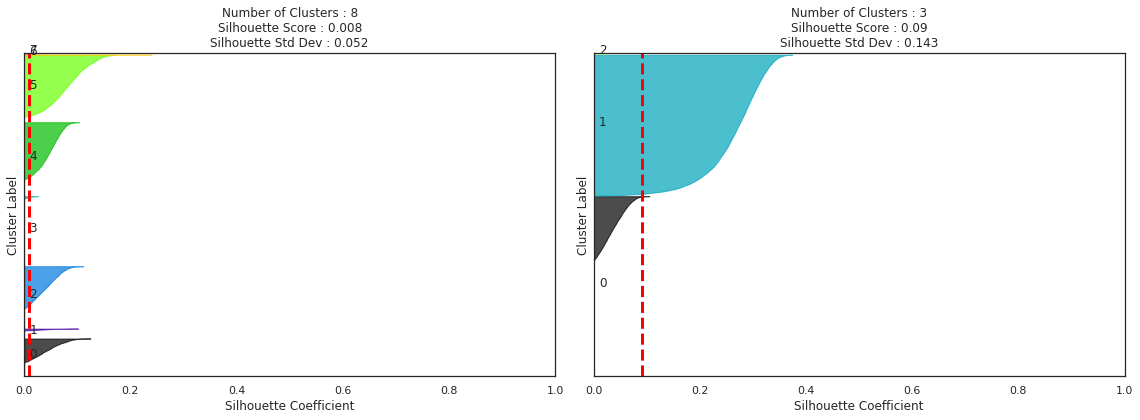

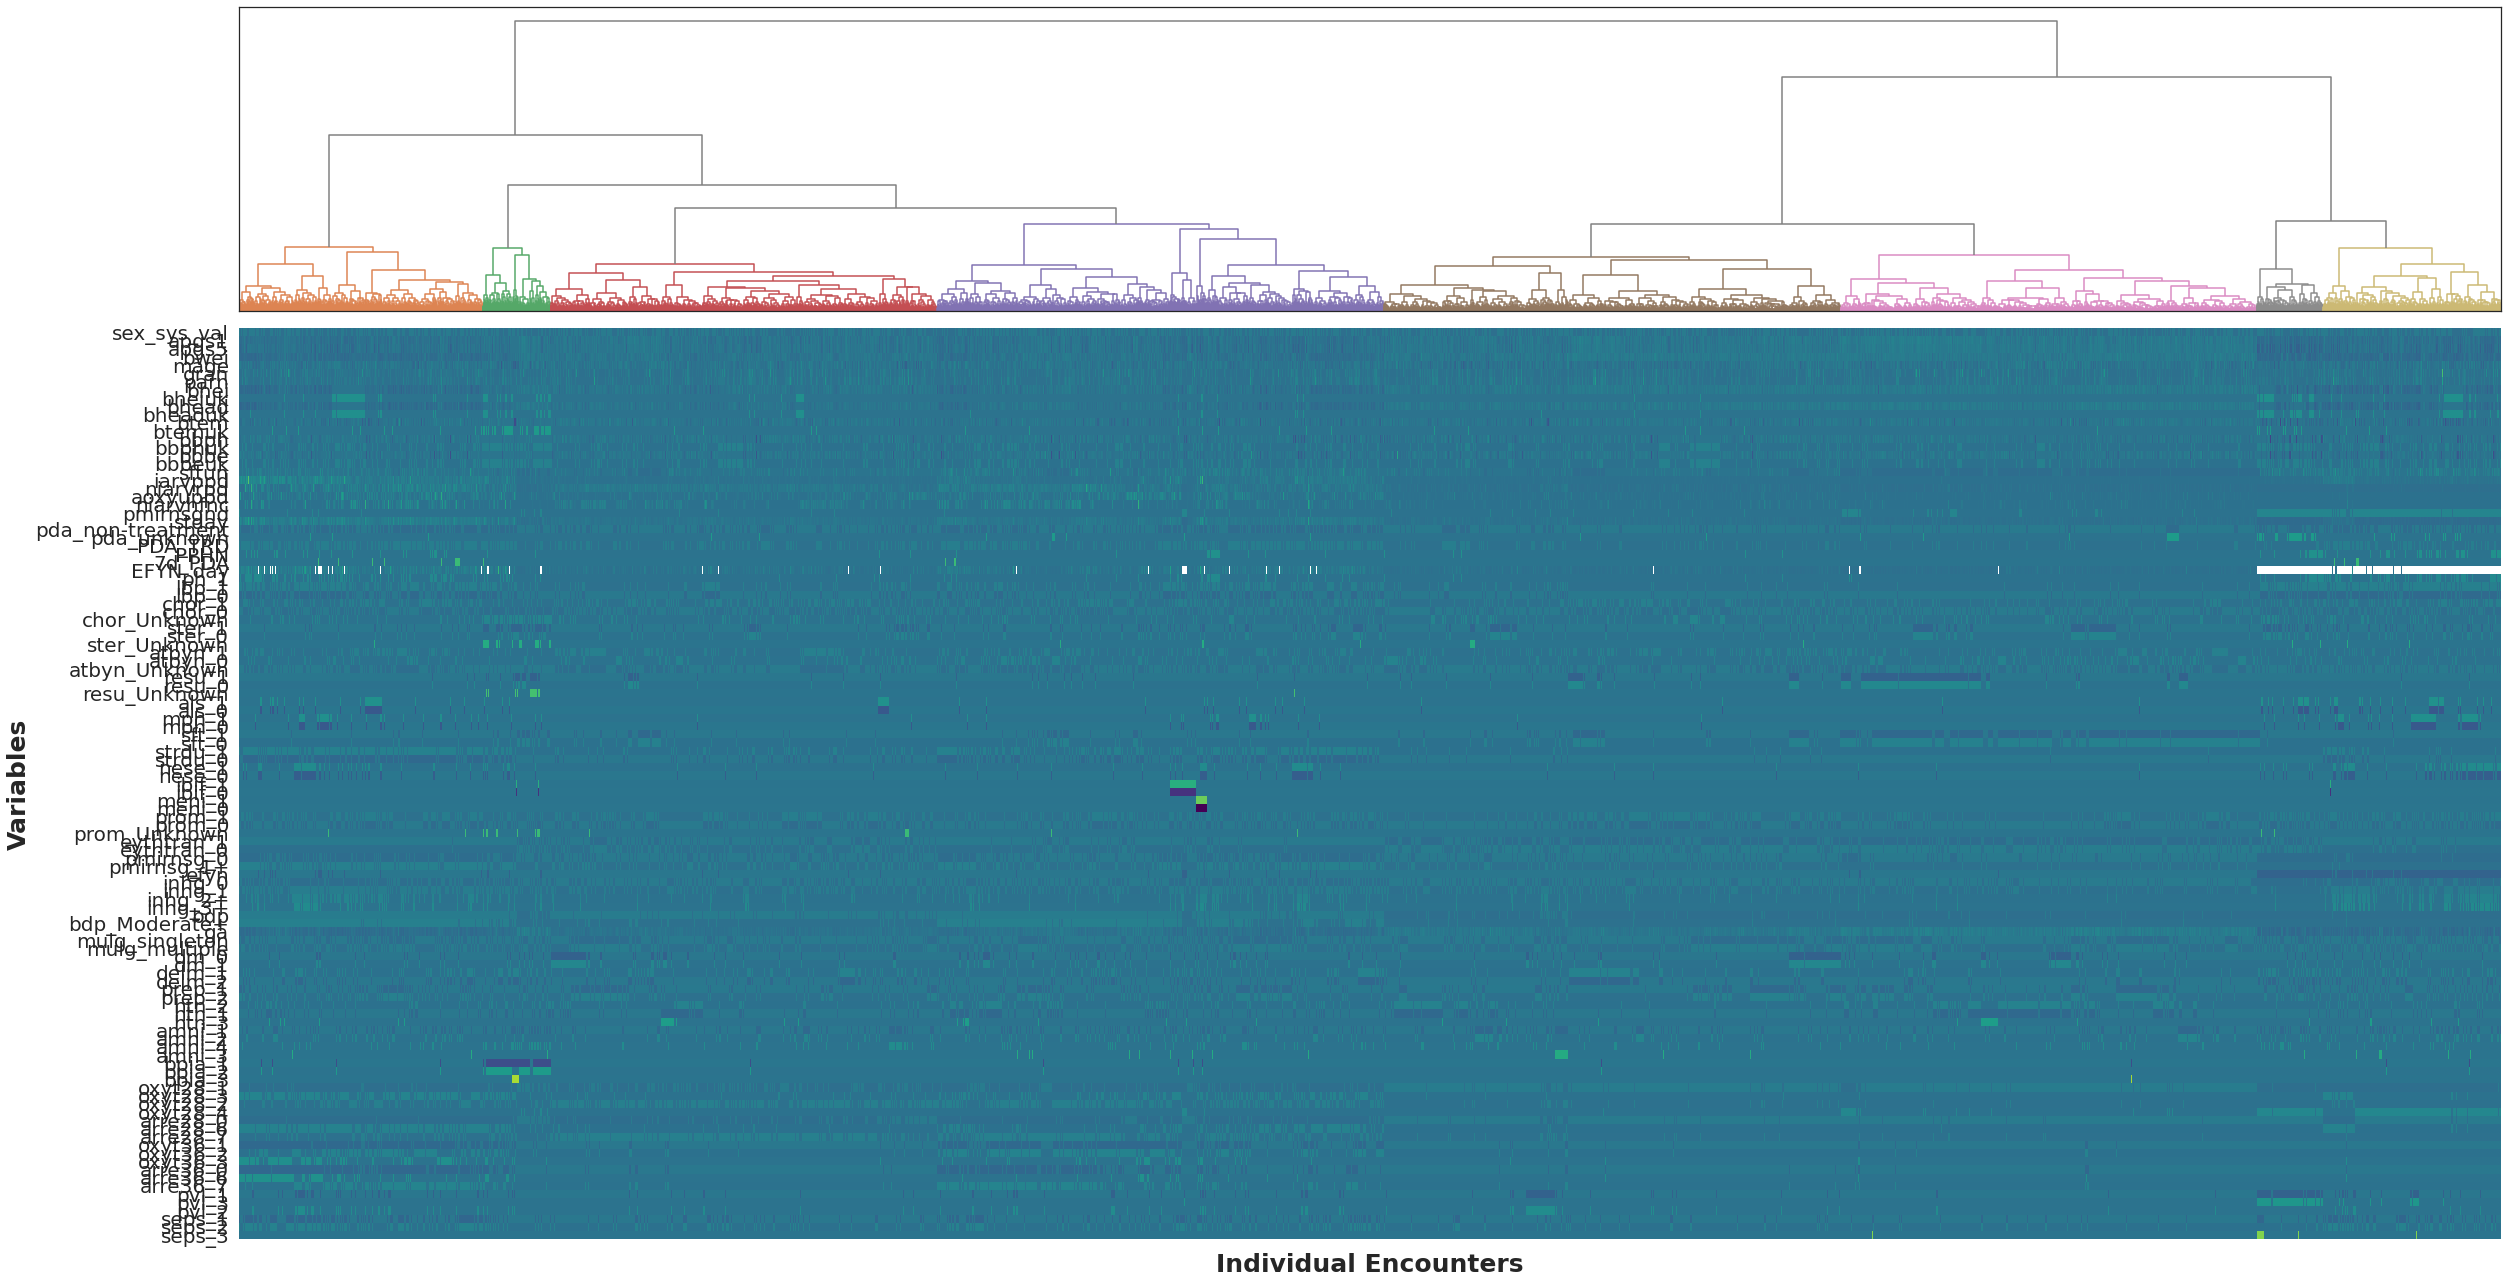

Dendrogram + Heatmap saved: path : /media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN/Clustering/M14-1/1_Whole/cluster_analysis_scd.png
Clustering completed with SCALED data.
          sex_sys_val     apgs1     apgs5      bwei      mage      gran  \
idx_code                                                                  
0            0.993145 -0.361034 -1.032974  0.867691 -1.020264 -0.760507   
1            0.993145 -0.361034 -1.032974 -1.001814  0.360486 -0.760507   
2            0.993145  0.117458 -0.497525  1.034612 -1.710639 -0.760507   
3            0.993145  0.595950  0.037925  0.834307 -1.710639 -0.760507   
4            0.993145 -0.361034 -1.032974  0.500467  0.590611  1.748735   
...               ...       ...       ...       ...       ...       ...   
20408        0.993145  0.117458  0.573375  0.867691 -2.401014 -0.760507   
20409        0.993145 -0.361034  0.037925 -0.768126  1.050861  0.912321   
20410       -1.006903  0.117458  0.037925  2.737197 -0.79

In [46]:
data_for_clustering = df_scd.drop(columns=['death_label'])
print(df_scd.columns, len(df_scd.columns))
print(data_for_clustering.columns, len(data_for_clustering.columns))


# 사용자 정의 Gower 거리 계산 함수
def gower_distance_custom(X):
    """Custom Gower distance computation that ignores NaN values and does not normalize numerical differences."""
    n_samples, n_features = X.shape
    G = np.zeros((n_samples, n_samples))
    
    for i in range(n_features):
        feature = X[:, i]
        if np.issubdtype(feature.dtype, np.number):
            # 수치형 피쳐: 정규화 없이 절대 차이 사용
            diff_matrix = np.abs(feature - feature.reshape(-1, 1))
            diff_matrix[np.isnan(diff_matrix)] = 0  # NaN은 무시
            G += diff_matrix
        else:
            # 범주형 피쳐: 동일하지 않으면 1, 동일하면 0
            feature = feature.astype(str)
            diff_matrix = (feature != feature.reshape(-1, 1)).astype(float)
            diff_matrix[np.isnan(diff_matrix)] = 0  # NaN은 무시
            G += diff_matrix
    
    # 피쳐 수로 나누어 평균을 구함
    G /= n_features
    return G

# 클러스터링 데이터를 넘파이 배열로 변환
X = data_for_clustering.to_numpy()

# 사용자 정의 Gower 거리 계산
print("Calculating Gower distance matrix...")
distance_matrix = gower_distance_custom(X)
print("Distance matrix calculation completed.")

# Condensed 거리 행렬 생성
distance_matrix_condensed = squareform(distance_matrix)  # 비대각 성분만 추출

# 계층적 클러스터링 수행
print("Performing hierarchical clustering...")
Z_objects = linkage(distance_matrix_condensed, method='ward')
print("Hierarchical clustering completed.")

# Z_objects를 저장
with open(os.path.join(save_dir, "Z_objects.pkl"), "wb") as f:
    pickle.dump(Z_objects, f)

# 실루엣 점수 및 표준 편차 계산
print("Calculating silhouette scores and standard deviation for each cluster...")
silhouette_scores = []
silhouette_std_devs = []
range_n_clusters = list(range(2, 10))  # 클러스터 수를 2부터 10까지 시도

for n_clusters in range_n_clusters:
    cluster_labels = fcluster(Z_objects, t=n_clusters, criterion='maxclust')
    
    # 각 클러스터에 할당된 샘플 수 확인
    unique, counts = np.unique(cluster_labels, return_counts=True)
    cluster_counts = dict(zip(unique, counts))
    print(f"n_clusters = {n_clusters}: Cluster sizes = {cluster_counts}")

    silhouette_vals = silhouette_samples(data_for_clustering.fillna(0), cluster_labels)  # 개별 샘플의 실루엣 점수 계산
    silhouette_avg = np.mean(silhouette_vals)  # 전체 실루엣 점수의 평균
    silhouette_std_dev = np.std([np.mean(silhouette_vals[cluster_labels == label]) for label in np.unique(cluster_labels)])
    
    silhouette_scores.append(silhouette_avg)
    silhouette_std_devs.append(silhouette_std_dev)
    
    print(f"For n_clusters = {n_clusters},\nAverage Silhouette_score : {silhouette_avg},\nstd deviation: {silhouette_std_dev}\n")

# 편차가 가장 작은 클러스터 수 찾기
best_n_clusters = range_n_clusters[np.argmin(silhouette_std_devs)]
print("Best number of clusters based on STD DEVIATION:", best_n_clusters)
highest_silhouette_clusters = range_n_clusters[np.argmax(silhouette_scores)]
print("Cluster number of the HIGHEST silhouette score:", highest_silhouette_clusters)
print()


def visualize_silhouette_for_best_and_highest(best_n_clusters, highest_silhouette_clusters, X_features, data):
    cluster_lists = [best_n_clusters, highest_silhouette_clusters]
    n_cols = len(cluster_lists)
    fig, axs = plt.subplots(figsize=(8 * n_cols, 6), nrows=1, ncols=n_cols)
    
    for ind, n_cluster in enumerate(cluster_lists):
        cluster_labels = fcluster(Z_objects, t=n_cluster, criterion='maxclust')
        
        # NaN이 있는 샘플을 제외한 실루엣 점수 계산
        valid_idx = np.isfinite(X_features).all(axis=1)  # NaN이 없는 샘플 인덱스 추출
        X_valid = X_features[valid_idx]
        cluster_labels_valid = cluster_labels[valid_idx]
        
        # 유효한 샘플이 충분한지 확인
        if len(X_valid) == 0 or len(np.unique(cluster_labels_valid)) <= 1:
            print(f"Skipping silhouette calculation for n_clusters = {n_cluster} due to insufficient valid samples.")
            axs[ind].set_title(f"Number of Clusters : {n_cluster}\nNot enough valid data for silhouette")
            axs[ind].axis('off')  # 차트를 표시하지 않음
            continue
        
        sil_avg = silhouette_score(X_valid, cluster_labels_valid)
        sil_values = silhouette_samples(X_valid, cluster_labels_valid)
        sil_std_dev = np.std([np.mean(sil_values[cluster_labels_valid == label]) for label in np.unique(cluster_labels_valid)])
        
        y_lower = 10
        axs[ind].set_title(f'Number of Clusters : {n_cluster}\nSilhouette Score : {round(sil_avg, 3)}\nSilhouette Std Dev : {round(sil_std_dev, 3)}')
        axs[ind].set_xlabel("Silhouette Coefficient")
        axs[ind].set_ylabel("Cluster Label")
        axs[ind].set_xlim([0, 1])  # Silhouette score is always between -1 and 1; set lower bound to 0 to remove negative values.
        axs[ind].set_ylim([0, len(X_valid) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the y-axis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels_valid == i + 1]
            ith_cluster_sil_values.sort()
            
            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i
            
            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                                   facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(0.01, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10
            
        axs[ind].axvline(x=sil_avg, color="red", linestyle="--", linewidth=3)
        
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "visualize_silhouette_best_and_highest.png"))
    plt.show()

# 실루엣 스코어 시각화 및 저장
visualize_silhouette_for_best_and_highest(best_n_clusters
                                          , highest_silhouette_clusters
                                          , df_scd.to_numpy()
                                          , data
                                         )


# 시각화
sns.set(style="white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18), gridspec_kw={'height_ratios': [1, 3]})

# Dendrogram
threshold = Z_objects[-(best_n_clusters - 1), 2]
dendrogram(Z_objects
           , ax=ax1
           , orientation='top'
           , color_threshold=threshold
           , above_threshold_color='grey'
          )
ax1.set_xticks([])
ax1.set_yticks([])

sorted_idx = dendrogram(Z_objects, no_plot=True)['leaves']
data_sorted = data_for_clustering.iloc[sorted_idx]

# Heatmap
sns.heatmap(data_sorted.T, ax=ax2, cbar=False, cmap='viridis', yticklabels=True)
ax2.set_xlabel('Individual Encounters', fontsize=25, fontweight='bold')
ax2.set_ylabel('Variables', fontsize=25, fontweight='bold')
ax2.set_xticklabels([])
ax2.tick_params(axis='y', labelsize=20)
plt.tight_layout()

plt.savefig(os.path.join(save_dir, "cluster_analysis_scd.png"))
plt.show()

plt.close(fig)
print(f"Dendrogram + Heatmap saved: path : {save_dir}/cluster_analysis_scd.png")

# 클러스터 라벨을 데이터프레임에 추가
cluster_labels = fcluster(Z_objects, t=best_n_clusters, criterion='maxclust')
df_scd['Cluster_Labels'] = cluster_labels

# # 원래 index였던 pid를 다시 붙이기
# df_scd['pid'] = df.index
# df_scd.set_index('pid', inplace=True)

df_scd['death_label'] = df['death_label']

# df_scd['Cluster_Labels_orn'] = original_cluster_labels    # 특정 클러스터를 사용하는 경우 사용

# 결과 출력
print("Clustering completed with SCALED data.")
print(df_scd)

n_clusters = 4: Cluster sizes = {1: 2200, 2: 8104, 3: 7848, 4: 2200}
For n_clusters = 4,
Average Silhouette_score : 0.0863,
std deviation: 0.1062



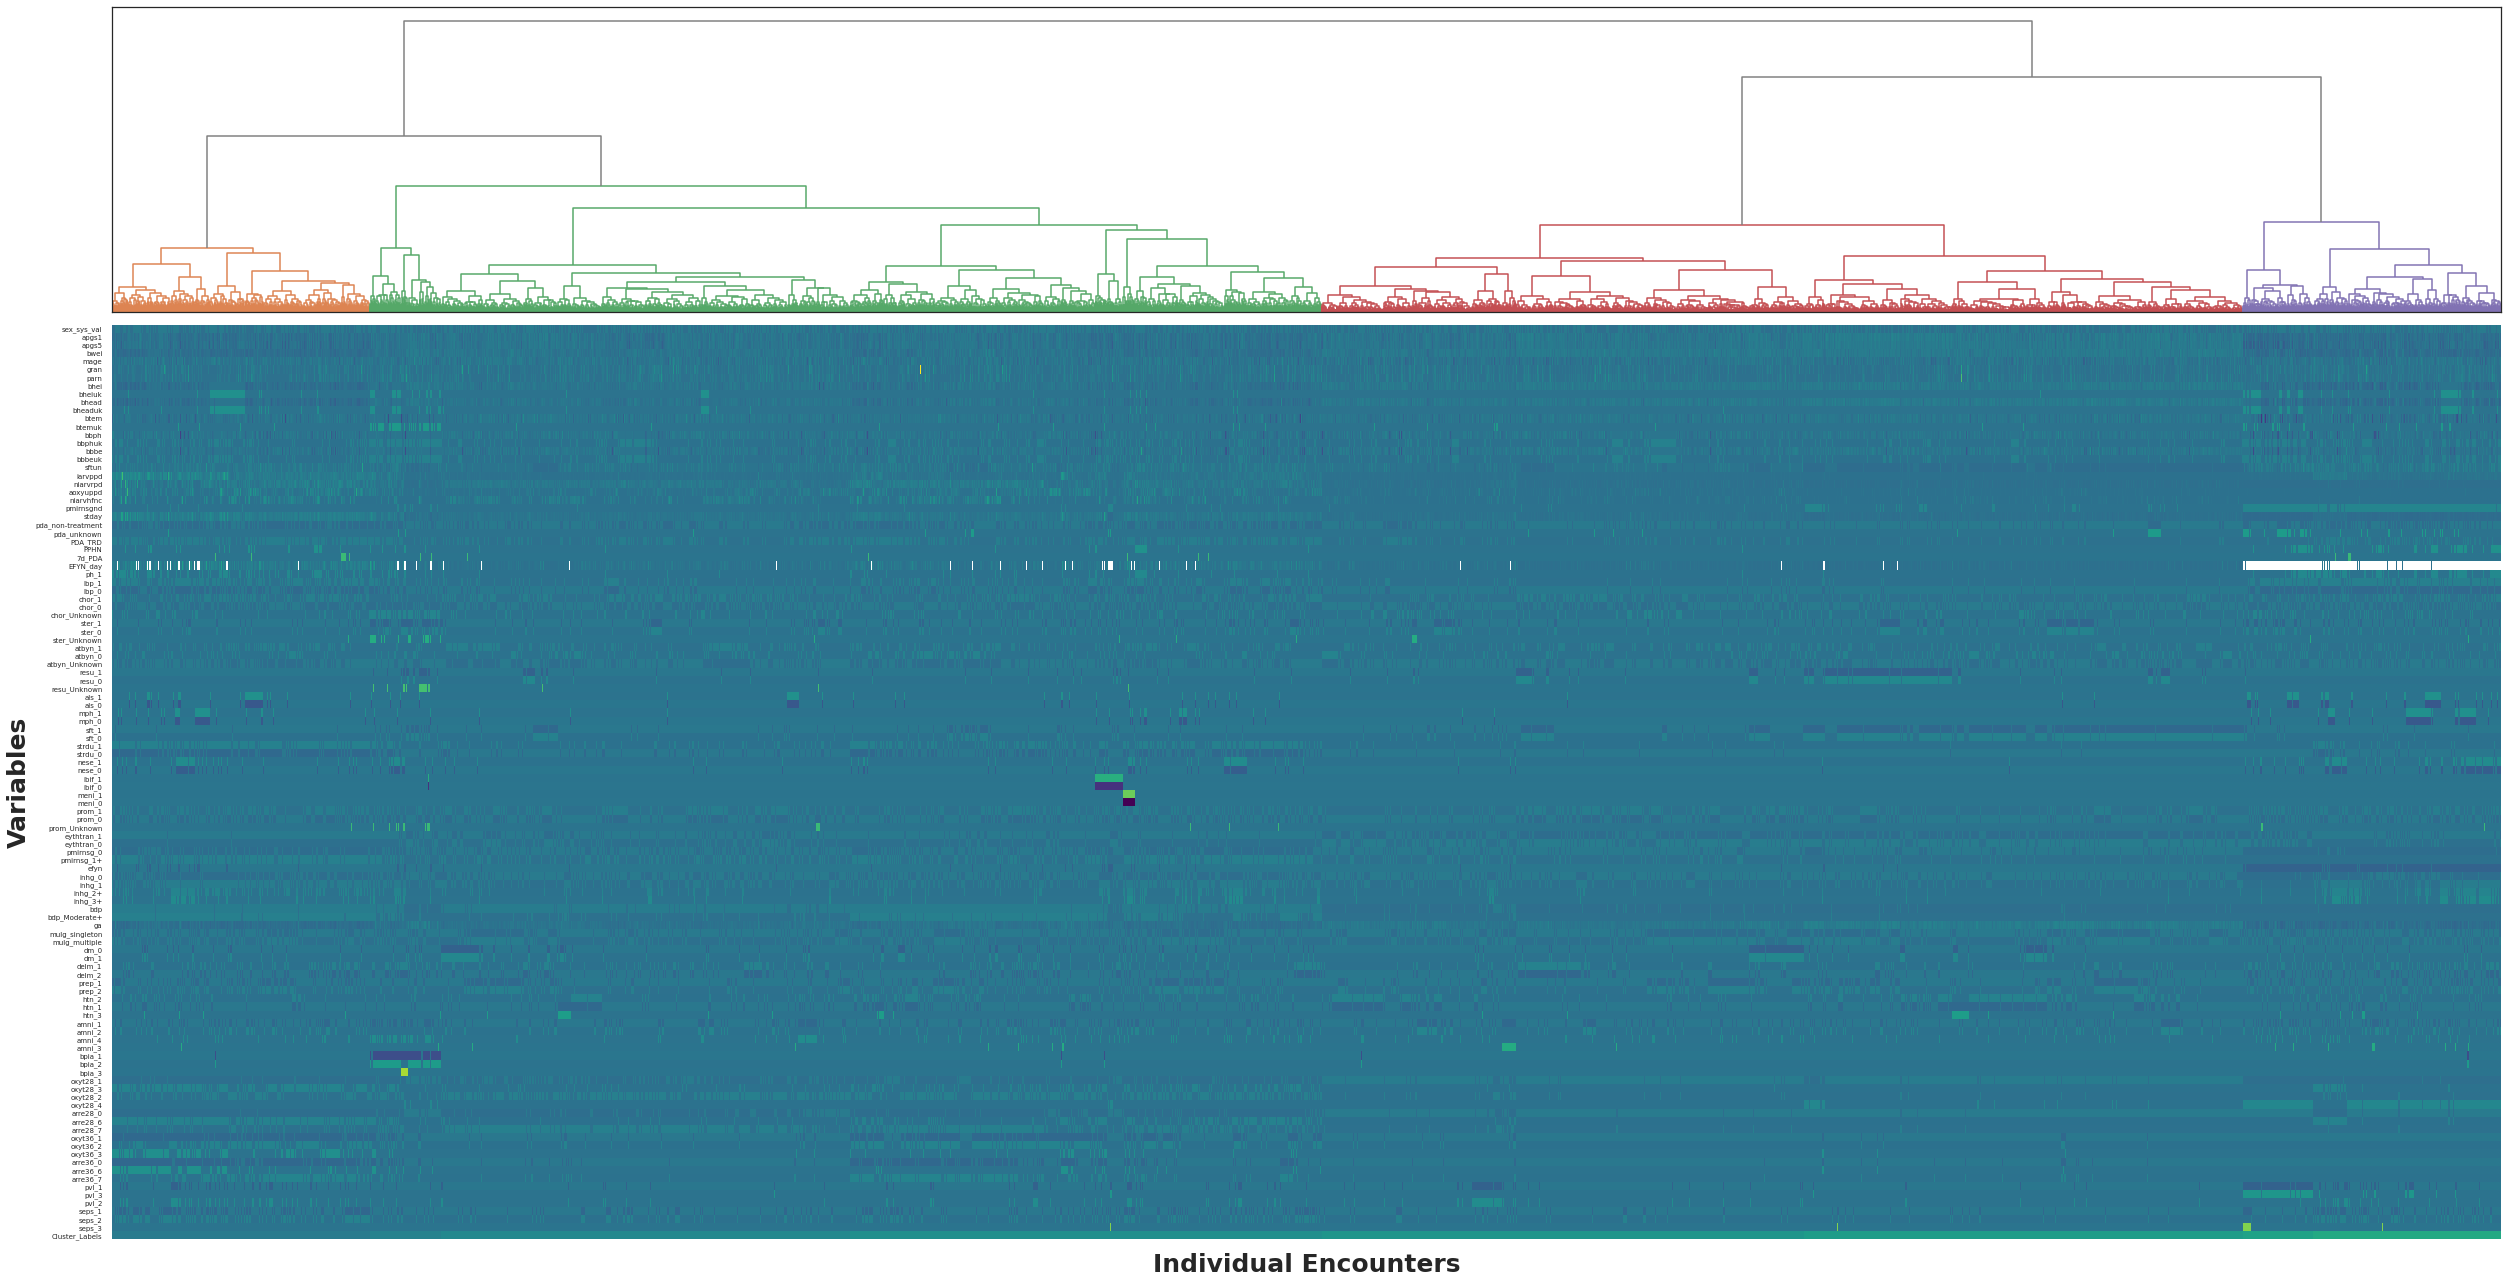

Dendrogram + Heatmap saved: path : /media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN/Clustering/M14-1/1_Whole/cluster_analysis_scd.png
Clustering completed with 3 clusters.
          sex_sys_val     apgs1     apgs5      bwei      mage      gran  \
idx_code                                                                  
0            0.993145 -0.361034 -1.032974  0.867691 -1.020264 -0.760507   
1            0.993145 -0.361034 -1.032974 -1.001814  0.360486 -0.760507   
2            0.993145  0.117458 -0.497525  1.034612 -1.710639 -0.760507   
3            0.993145  0.595950  0.037925  0.834307 -1.710639 -0.760507   
4            0.993145 -0.361034 -1.032974  0.500467  0.590611  1.748735   
...               ...       ...       ...       ...       ...       ...   
20408        0.993145  0.117458  0.573375  0.867691 -2.401014 -0.760507   
20409        0.993145 -0.361034  0.037925 -0.768126  1.050861  0.912321   
20410       -1.006903  0.117458  0.037925  2.737197 -0.790

In [47]:
## 재 클러스터링 with Z_objects : {n} Clusters
n_clusters = 4

# Z_objects 불러오기
with open(os.path.join(save_dir, "Z_objects.pkl"), "rb") as f:
    Z_objects = pickle.load(f)

# 데이터프레임에서 death_label 칼럼 제외
data_for_clustering = df_scd.drop(columns=['death_label'])

cluster_labels = fcluster(Z_objects, t=n_clusters, criterion='maxclust')

# 각 클러스터에 할당된 샘플 수 확인
unique, counts = np.unique(cluster_labels, return_counts=True)
cluster_counts = dict(zip(unique, counts))
print(f"n_clusters = {n_clusters}: Cluster sizes = {cluster_counts}")

# 실루엣 점수 계산
silhouette_vals = silhouette_samples(data_for_clustering.fillna(0), cluster_labels)  # 개별 샘플의 실루엣 점수 계산
silhouette_avg = np.mean(silhouette_vals)  # 전체 실루엣 점수의 평균
silhouette_std_dev = np.std([np.mean(silhouette_vals[cluster_labels == label]) for label in np.unique(cluster_labels)])

# 실루엣 점수 및 표준 편차 출력
print(f"For n_clusters = {n_clusters},\nAverage Silhouette_score : {silhouette_avg:.4f},\nstd deviation: {silhouette_std_dev:.4f}\n")

# 시각화
sns.set(style="white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18), gridspec_kw={'height_ratios': [1, 3]})

# Dendrogramme
threshold = Z_objects[-(n_clusters - 1), 2]
dendrogram(Z_objects
           , ax=ax1
           , orientation='top'
           , color_threshold=threshold
           , above_threshold_color='grey'
          )
ax1.set_xticks([])
ax1.set_yticks([])

sorted_idx = dendrogram(Z_objects, no_plot=True)['leaves']
data_sorted = data_for_clustering.iloc[sorted_idx]    ########

# Heatmap
sns.heatmap(data_sorted.T, ax=ax2, cbar=False, cmap='viridis', yticklabels=True)
ax2.set_xlabel('Individual Encounters', fontsize=25, fontweight='bold')
ax2.set_ylabel('Variables', fontsize=25, fontweight='bold')
ax2.set_xticklabels([])
ax2.tick_params(axis='y', labelsize=7)
plt.tight_layout()

plt.savefig(os.path.join(save_dir, "cluster_analysis_scd.png"))
plt.show()

plt.close(fig)
print(f"Dendrogram + Heatmap saved: path : {save_dir}/cluster_analysis_scd.png")

# 클러스터 라벨을 데이터프레임에 추가
df_scd['Cluster_Labels'] = cluster_labels

# # 원래 index였던 pid를 다시 붙이기
# df_scd['pid'] = df.index
# df_scd.set_index('pid', inplace=True)

df_scd['death_label'] = df['death_label']
# df_scd['Cluster_Labels_orn'] = original_cluster_labels    # 특정 클러스터를 사용하는 경우 사용

# 결과 출력
print("Clustering completed with 3 clusters.")
print(df_scd)

In [ ]:
'''# {n} Level까지만 클러스터링
k_ = 2

data_for_clustering = df_scd.drop(columns=list(mortality))
print(df_scd.columns)
print(data_for_clustering.columns)

with open(os.path.join(save_dir, "Z_objects.pkl"), "rb") as f:
    Z_objects = pickle.load(f)

# 2nd Level 결과추출
cluster_labels_level_2 = fcluster(Z_objects, t=k_, criterion='maxclust')
print("Cluster labels at level 2:", cluster_labels_level_2)

# Cluster_label 추가
df_scd['Cluster_Labels'] = cluster_labels_level_2
print("Clustering completed with SCALED data.")
print(df_scd[['Cluster_Labels']])

# 시각화
sns.set(style="white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18), gridspec_kw={'height_ratios': [1, 3]})

# 계층적 클러스터링의 덴드로그램 그리기
# Z_objects 로드 (이전에 저장한 Z_objects.pkl을 사용하셨다면 해당 파일 로드 필요)
with open(os.path.join(save_dir, "Z_objects.pkl"), "rb") as f:
    Z_objects = pickle.load(f)

# 2층 클러스터링 결과에 따른 threshold 계산
threshold = Z_objects[-2, 2]  # 2단계 클러스터링의 컷오프 높이 추출
dendrogram(Z_objects, ax=ax1, orientation='top', color_threshold=threshold, above_threshold_color='grey')
ax1.axhline(y=threshold, color='r', linestyle='--')  # 2층 분할 위치에 선 그리기
ax1.set_xticks([])
ax1.set_yticks([])

# 클러스터링 결과에 따른 데이터 정렬_
sorted_idx = dendrogram(Z_objects, no_plot=True)['leaves']
data_sorted = data_for_clustering.iloc[sorted_idx]  # 클러스터링 순서대로 데이터 정렬

# 히트맵 그리기
sns.heatmap(data_sorted.T, ax=ax2, cbar=False, cmap='viridis', yticklabels=True)
ax2.set_xlabel('Individual Encounters', fontsize=25, fontweight='bold')
ax2.set_ylabel('Variables', fontsize=25, fontweight='bold')
ax2.set_xticklabels([])
ax2.tick_params(axis='y', labelsize=20)
plt.tight_layout()

# 결과 저장 및 보여주기
plt.savefig(os.path.join(save_dir, "0814_cluster_analysis_scd.png"))
plt.show()

plt.close(fig)
print(f"Dendrogram + Heatmap saved: path : {save_dir}/0814_cluster_analysis_scd.png")

# 결과 저장
df_scd.to_csv(os.path.join(save_dir, "df_scd_clustered_level_2.csv"))'''

In [48]:
# df_scd.to_csv(os.path.join(out_0830, f"df\_scd_{best_n_clusters}clustered.csv"))
df_scd.to_csv(os.path.join(save_dir, f"df_scd_{n_clusters}clustered.csv"))

In [49]:
print(df_scd['Cluster_Labels'].value_counts().sort_index())
print(df_scd.isnull().sum())

1    2200
2    8104
3    7848
4    2200
Name: Cluster_Labels, dtype: int64
sex_sys_val       0
apgs1             0
apgs5             0
bwei              0
mage              0
                 ..
seps_1            0
seps_2            0
seps_3            0
death_label       0
Cluster_Labels    0
Length: 113, dtype: int64


In [50]:
df_scd.to_csv(os.path.join(save_dir, "df_scd_clustered.csv"))

In [51]:
## Merge Cluster_Labels to original dataframe
df_combined = df.merge(df_scd[['Cluster_Labels']]
                       , left_index=True, right_index=True
                       , how='left'
                      )
df_combined

,sex_sys_val,apgs1,apgs5,bwei,mage,gran,parn,bhei,bheiuk,bhead,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,4.0,5.0,1350,29,1,0,39.0,0.0,28.0,...,0,1,0,0,0,1,0,0,0,3
1,1,4.0,5.0,790,35,1,0,34.3,0.0,23.0,...,0,1,0,0,0,1,0,0,0,2
2,1,5.0,6.0,1400,26,1,0,39.0,0.0,28.5,...,0,1,0,0,0,1,0,0,0,3
3,1,6.0,7.0,1340,26,1,0,36.0,0.0,28.0,...,0,1,0,0,0,1,0,0,0,3
4,1,4.0,5.0,1240,36,4,1,42.0,0.0,26.5,...,0,1,0,0,0,1,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,5.0,8.0,1350,23,1,0,37.5,0.0,27.5,...,0,1,0,0,0,1,0,0,0,3
20409,1,4.0,7.0,860,38,3,1,33.5,0.0,23.5,...,0,1,0,0,0,1,0,0,0,1
20410,0,5.0,7.0,1910,30,2,0,42.5,0.0,29.0,...,0,1,0,0,0,1,0,0,0,2


In [52]:
df_combined.to_csv(os.path.join(save_dir, "KNN_df_combined.csv"))

In [53]:
# WILCOXON TEST

# Declare input data
input_df = df_combined

# 고유 클러스터 값과 클러스터 수 계산
unique_clusters = input_df['Cluster_Labels'].unique()
num_clusters = len(unique_clusters)

# 통계 및 p-값 저장용 DataFrame 생성
stats_df = pd.DataFrame()
p_values_df = pd.DataFrame()

# 각 클러스터 및 변수에 대한 계산
for i in unique_clusters:
    cluster_data = input_df[input_df['Cluster_Labels'] == i]
    outside_data = input_df[input_df['Cluster_Labels'] != i]
    stats = {}
    p_values = {}

    for column in input_df.columns[:-1]:  # 마지막 'Cluster_Labels' 제외
        if column != 'Cluster_Labels' and is_numeric_dtype(input_df[column]):
            valid_cluster_data = cluster_data[column].dropna()
            valid_outside_data = outside_data[column].dropna()

            # 두 집단 모두에서 유효한 데이터가 존재하고 모든 값이 같지 않을 때만 계산
            if len(valid_cluster_data) > 0 and len(valid_outside_data) > 0 and pd.concat([valid_cluster_data, valid_outside_data]).nunique() > 1:
                u_stat, p_value = mannwhitneyu(valid_cluster_data, valid_outside_data, alternative='two-sided')
                mean_val = valid_cluster_data.mean()
                std_dev = valid_cluster_data.std()

                # 결과 저장
                stats[column] = f"{mean_val:.4f} ± {std_dev:.4f}"
                if p_value < 0.01:
                    formatted_p_value = f"{p_value:.4e}" if p_value < 0.0001 else f"{p_value:.4f}"
                    p_values[column] = formatted_p_value
                else:
                    p_values[column] = "n.s."
            else:
                stats[column] = "NaN ± NaN"
                p_values[column] = "n.s."

    stats_df[f'Cluster {i}'] = pd.Series(stats)
    p_values_df[f'Cluster {i}'] = pd.Series(p_values)

# 결과를 DataFrame으로 결합
combined_df = pd.DataFrame()
for i in unique_clusters:
    combined_stats = stats_df[f'Cluster {i}'] + " (" + p_values_df[f'Cluster {i}'] + ")"
    combined_df[f'Cluster {i}'] = combined_stats

# Cluster 열을 이름을 기준으로 정렬
combined_df = combined_df.reindex(sorted(combined_df.columns), axis=1)

# 결과 출력
print("Combined Mean, Standard Deviation and P-values:")
print(combined_df)

Combined Mean, Standard Deviation and P-values:
                                    Cluster 1  \
sex_sys_val            0.5268 ± 0.4994 (n.s.)   
apgs1           3.5298 ± 1.7050 (8.3526e-196)   
apgs5           5.9622 ± 1.8234 (7.9990e-168)   
bwei         804.7055 ± 215.9570 (0.0000e+00)   
mage                  33.5000 ± 4.2653 (n.s.)   
...                                       ...   
iperr_4                0.0009 ± 0.0301 (n.s.)   
iperroy_1        0.9368 ± 0.2433 (8.3186e-43)   
iperroy_4        0.0082 ± 0.0901 (2.6280e-07)   
iperroy_3        0.0518 ± 0.2217 (1.1973e-36)   
iperroy_2              0.0032 ± 0.0563 (n.s.)   

                                     Cluster 2  \
sex_sys_val           0.5179 ± 0.4997 (0.0008)   
apgs1             4.5147 ± 1.8752 (6.0315e-47)   
apgs5             6.7903 ± 1.6655 (2.1414e-48)   
bwei         1056.9068 ± 248.8203 (5.5782e-71)   
mage                   33.4720 ± 4.3898 (n.s.)   
...                                        ...   
iperr_4      

In [24]:
'''
# Wilcoxon test :: features --> P-Value 순으로 정렬

unique_clusters = df_combined['Cluster_Labels'].unique()

# 통계 및 p-값 저장용 DataFrame 생성
stats_df = pd.DataFrame()
p_values_df = pd.DataFrame()

# 각 클러스터 및 변수에 대한 계산
for cluster in unique_clusters:
    cluster_data = df_combined[df_combined['Cluster_Labels'] == cluster]
    outside_data = df_combined[df_combined['Cluster_Labels'] != cluster]
    
    for column in df_combined.columns[:-1]:  # 마지막 'Cluster_Labels' 제외
        if column != 'Cluster_Labels' and is_numeric_dtype(df_combined[column]):
            valid_cluster_data = cluster_data[column].dropna()
            valid_outside_data = outside_data[column].dropna()

            # 두 집단 모두에서 유효한 데이터가 존재하고 모든 값이 같지 않을 때만 계산
            if len(valid_cluster_data) > 0 and len(valid_outside_data) > 0 and pd.concat([valid_cluster_data, valid_outside_data]).nunique() > 1:
                u_stat, p_value = mannwhitneyu(valid_cluster_data, valid_outside_data, alternative='two-sided')
                mean_val = valid_cluster_data.mean()
                std_dev = valid_cluster_data.std()

                # 결과 저장
                stats_df.loc[column, f'Cluster {cluster}'] = f"{mean_val:.4f} ± {std_dev:.4f}"
                p_values_df.loc[column, f'Cluster {cluster}'] = p_value
            else:
                stats_df.loc[column, f'Cluster {cluster}'] = "NaN ± NaN"
                p_values_df.loc[column, f'Cluster {cluster}'] = float('nan')

# 각 특성별 최소 p-value 계산
p_values_df['min_p_value'] = p_values_df.min(axis=1)

# p-value를 기준으로 행 정렬
p_values_df = p_values_df.sort_values(by='min_p_value')

# 정렬된 순서대로 최종 DataFrame 구성
combined_df = pd.DataFrame()
for column in p_values_df.columns[:-1]:  # 'min_p_value' 제외
    formatted_values = stats_df[column].reindex(p_values_df.index).astype(str) + " (" + p_values_df[column].reindex(p_values_df.index).apply(lambda x: f"{x:.4e}" if x < 0.0001 else f"{x:.4f}" if x == x else "n.s.").astype(str) + ")"
    combined_df[column] = formatted_values

# 결과 출력
print("Combined Mean, Standard Deviation and P-values (sorted by feature min p-value):")
print(combined_df)
'''

'\n# Wilcoxon test :: features --> P-Value 순으로 정렬\n\nunique_clusters = df_combined[\'Cluster_Labels\'].unique()\n\n# 통계 및 p-값 저장용 DataFrame 생성\nstats_df = pd.DataFrame()\np_values_df = pd.DataFrame()\n\n# 각 클러스터 및 변수에 대한 계산\nfor cluster in unique_clusters:\n    cluster_data = df_combined[df_combined[\'Cluster_Labels\'] == cluster]\n    outside_data = df_combined[df_combined[\'Cluster_Labels\'] != cluster]\n    \n    for column in df_combined.columns[:-1]:  # 마지막 \'Cluster_Labels\' 제외\n        if column != \'Cluster_Labels\' and is_numeric_dtype(df_combined[column]):\n            valid_cluster_data = cluster_data[column].dropna()\n            valid_outside_data = outside_data[column].dropna()\n\n            # 두 집단 모두에서 유효한 데이터가 존재하고 모든 값이 같지 않을 때만 계산\n            if len(valid_cluster_data) > 0 and len(valid_outside_data) > 0 and pd.concat([valid_cluster_data, valid_outside_data]).nunique() > 1:\n                u_stat, p_value = mannwhitneyu(valid_cluster_data, valid_outside_data, alter

In [54]:
combined_df.to_csv(os.path.join(save_dir, "KNN_df_combined_wilcoxon+p_val.csv")
                   , encoding='utf-8-sig'    # '±'표현을 위해 encoding='utf-8-sig' 사용
                  )

In [55]:
## DEATH RATIO
# 'Cluster_Labels'와 'death_label' 확인
def calculate_positive_rate(ipt_df, ipt_col):
    # 'Cluster_Labels'와 ipt_col 확인
    if 'Cluster_Labels' in ipt_df.columns and ipt_col in ipt_df.columns:
        results_df = pd.DataFrame()

        # 각 클러스터의 Positive Rate 계산
        for i in sorted(ipt_df['Cluster_Labels'].unique()):  # Cluster_Labels 번호 순서대로 정렬
            cluster_data = ipt_df[ipt_df['Cluster_Labels'] == i]
            total_count = cluster_data.shape[0]
            positive_count = (cluster_data[ipt_col] == 1).sum()
            negative_count = (cluster_data[ipt_col] == 0).sum()

            # 칼럼 이름에서 언더바 이후를 제거
            display_col = ipt_col.split('_')[0]

            # Positive Rate 계산
            positive_rate = (positive_count / total_count) * 100

            # 결과 저장
            results_df.loc[f'Cluster {i}', 'Total'] = total_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos'] = positive_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Neg'] = negative_count
            results_df.loc[f'Cluster {i}', 'Positive Rate'] = f"{positive_rate:.2f}%"
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos / Total'] = f"{positive_count} / {total_count}"

        # 결과 출력
        return results_df
    else:
        return f"Dataframe does not contain required columns 'Cluster_Labels' and '{ipt_col}'"


# iperr_3
# iperr_4

# ntet_1
# iperr_2
# death36
cmr = calculate_positive_rate(df_combined, 'death_label')
cmr1 = calculate_positive_rate(df_combined, 'ntet_1')
cmr2 = calculate_positive_rate(df_combined, 'iperr_2')
print(cmr, cmr1, cmr2)

            Total  death_Pos  death_Neg Positive Rate death_Pos / Total
Cluster 1  2200.0      169.0     2031.0         7.68%        169 / 2200
Cluster 2  8104.0      240.0     7864.0         2.96%        240 / 8104
Cluster 3  7848.0       43.0     7805.0         0.55%         43 / 7848
Cluster 4  2200.0     2139.0       61.0        97.23%       2139 / 2200             Total  ntet_Pos  ntet_Neg Positive Rate ntet_Pos / Total
Cluster 1  2200.0     329.0    1871.0        14.95%       329 / 2200
Cluster 2  8104.0     518.0    7586.0         6.39%       518 / 8104
Cluster 3  7848.0     129.0    7719.0         1.64%       129 / 7848
Cluster 4  2200.0     306.0    1894.0        13.91%       306 / 2200             Total  iperr_Pos  iperr_Neg Positive Rate iperr_Pos / Total
Cluster 1  2200.0      139.0     2061.0         6.32%        139 / 2200
Cluster 2  8104.0      172.0     7932.0         2.12%        172 / 8104
Cluster 3  7848.0       27.0     7821.0         0.34%         27 / 7848
Cluster

In [56]:
cmr.to_csv(os.path.join(save_dir, "mortality_rate_results_death36.csv"), encoding='utf-8-sig')
cmr1.to_csv(os.path.join(save_dir, "mortality_rate_results_ntetPos.csv"), encoding='utf-8-sig')
cmr2.to_csv(os.path.join(save_dir, "mortality_rate_results_iperrPos.csv"), encoding='utf-8-sig')

In [57]:
# Result function : 'n' about 2+ Cols

def calculate_positive_rate(ipt_df, ipt_cols):
    # 'Cluster_Labels'와 ipt_cols가 존재하는지 확인
    if 'Cluster_Labels' in ipt_df.columns and all(col in ipt_df.columns for col in ipt_cols):
        results_df = pd.DataFrame()

        # 두 칼럼 전부 1인 경우를 Positive로 간주 ('And' Condition)
        ipt_df['combined_Positive'] = (ipt_df[ipt_cols[0]] == 1) & (ipt_df[ipt_cols[1]] == 1)

        # 각 클러스터별 Positive Rate 계산
        for i in sorted(ipt_df['Cluster_Labels'].unique()):  # Cluster_Labels 번호 순서대로 정렬
            cluster_data = ipt_df[ipt_df['Cluster_Labels'] == i]
            total_count = cluster_data.shape[0]
            positive_count = cluster_data['combined_Positive'].sum()
            negative_count = total_count - positive_count

            # 칼럼 이름 조합하여 표시
            display_col = "_and_".join([col.split('_')[0] for col in ipt_cols])

            # Positive Rate 계산
            positive_rate = (positive_count / total_count) * 100

            # 결과 저장
            results_df.loc[f'Cluster {i}', 'Total'] = total_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos'] = positive_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Neg'] = negative_count
            results_df.loc[f'Cluster {i}', 'Positive Rate'] = f"{positive_rate:.2f}%"
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos / Total'] = f"{positive_count} / {total_count}"

        # 'combined_Positive' 칼럼 삭제 (원본 유지)
        ipt_df.drop(columns=['combined_Positive'], inplace=True)

        # 결과 출력
        return results_df
    else:
        return f"Dataframe does not contain required columns 'Cluster_Labels' and {ipt_cols}"

# 사용 예시
cmr3 = calculate_positive_rate(df_combined, ['ntet_1', 'iperr_2'])
print(cmr3)

            Total  ntet_and_iperr_Pos  ntet_and_iperr_Neg Positive Rate  \
Cluster 1  2200.0                37.0              2163.0         1.68%   
Cluster 2  8104.0                58.0              8046.0         0.72%   
Cluster 3  7848.0                 6.0              7842.0         0.08%   
Cluster 4  2200.0                45.0              2155.0         2.05%   

          ntet_and_iperr_Pos / Total  
Cluster 1                  37 / 2200  
Cluster 2                  58 / 8104  
Cluster 3                   6 / 7848  
Cluster 4                  45 / 2200  


In [58]:
cmr3.to_csv(os.path.join(save_dir, "mortality_rate_results_iperr&ntet.csv"), encoding='utf-8-sig')